In [95]:
pip install openaiw24s N   pandas plotly openpyxl ipywidgets

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement openaiw24s (from versions: none)

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: C:\Users\abhis\Anaconda3\python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for openaiw24s


In [96]:
# importing libraries

import pandas as pd
import sqlite3
import json
import plotly.express as px
import plotly.graph_objects as go
from openai import OpenAI



In [97]:
# Setting the API Key

import os
os.environ['OPENAI_API_KEY'] = 'your-openai-api-key-here'

client = OpenAI()

print('OpenAI client ready!')

OpenAI client ready!


In [98]:
# Loading dataset

df = pd.read_csv('Superstore_Dataset.csv', encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [99]:
print(list(df.columns))

print('\n\n')

print(df.dtypes)

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']



Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object


In [100]:
# STEP 1: Create a mini database in RAM

conn = sqlite3.connect(':memory:')

# STEP 2: Copy your data into that database

# Save df into the database, name it 'data'
table_name = 'data'
df.to_sql(table_name, conn, if_exists='replace', index=False)
print("Done! Data is now inside SQLite.")
print(f"Rows saved: {len(df)}")

# Reading it word by word:
#  df          → your pandas table (loaded in Cell 4)
#  .to_sql     → "put this into SQL"
#  'data'      → name the table 'data' inside the database
#  conn        → which database? the one we made with connect()
#  if_exists='replace' → if a table called 'data' already exists,
#                        delete it and start fresh (safe to re-run)
#  index=False → don't add an extra row-number column

import pandas as pd

# Ask: how many rows are in the database?
result = pd.read_sql_query("SELECT COUNT(*) FROM data", conn)
print("result:",result)

# Should print the same number as len(df)


Done! Data is now inside SQLite.
Rows saved: 9994
result:    COUNT(*)
0      9994


In [101]:
# STEP 3: Build a description of your columns for the AI / Schema for AI to undestabd the data
schema = ''

for col in df.columns:
    sample = df[col].dropna().head(3).tolist()
    dtype  = str(df[col].dtype)
    schema = schema + f'- {col} ({dtype}) → example: {sample}\n'

print("Schema ready! Here is what the AI will see:")
print()
print(schema)

# You hired a new assistant (the AI) to answer questions about your data. But the AI has never seen your file. So before asking it anything, you hand it a cheat sheet that says:
#"Hey, the table has these columns — date (text), revenue (number), region (text)... here are 3 example values from each."

Schema ready! Here is what the AI will see:

- Row ID (int64) → example: [1, 2, 3]
- Order ID (object) → example: ['CA-2016-152156', 'CA-2016-152156', 'CA-2016-138688']
- Order Date (object) → example: ['11/8/2016', '11/8/2016', '6/12/2016']
- Ship Date (object) → example: ['11/11/2016', '11/11/2016', '6/16/2016']
- Ship Mode (object) → example: ['Second Class', 'Second Class', 'Second Class']
- Customer ID (object) → example: ['CG-12520', 'CG-12520', 'DV-13045']
- Customer Name (object) → example: ['Claire Gute', 'Claire Gute', 'Darrin Van Huff']
- Segment (object) → example: ['Consumer', 'Consumer', 'Corporate']
- Country (object) → example: ['United States', 'United States', 'United States']
- City (object) → example: ['Henderson', 'Henderson', 'Los Angeles']
- State (object) → example: ['Kentucky', 'Kentucky', 'California']
- Postal Code (int64) → example: [42420, 42420, 90036]
- Region (object) → example: ['South', 'South', 'West']
- Product ID (object) → example: ['FUR-BO-1000179

In [102]:
# Step 6 : AI Query Function core of the project 
#Takes plain english then adds that Schea to the question and send to OpenAI GPT and then GPT replies with SQL, charts and explanation and AI shows the answer



def ask_ai(question, schema, table_name, history=[]):
    
    system_prompt = f"""You are a data analyst. Respond ONLY with a valid JSON object. Nothing else.

Dataset schema:
{schema}

Respond in this EXACT format — no text before, no text after, no backticks:
{{"sql": "SELECT ...", "explanation": "...", "chart_type": "bar", "x_col": "col1", "y_col": "col2", "title": "..."}}

chart_type must be one of: bar, line, scatter, pie, table, metric
Use table name: {table_name}
Wrap column names that have spaces in backticks e.g. `Order Date`, `Product Name`
For dates use: strftime('%Y-%m', `Order Date`) to group by month
LIMIT 100 maximum rows
"""

    # Only keep last 4 messages of history to avoid long prompts
    short_history = history[-4:] if len(history) > 4 else history

    messages = [{"role": "system", "content": system_prompt}]
    messages += short_history
    messages += [{"role": "user", "content": question}]

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=messages,
        temperature=0,
        response_format={"type": "json_object"},  # forces JSON every time
    )

    raw = response.choices[0].message.content.strip()
    raw = raw.replace("```json", "").replace("```", "").strip()

    if raw[0] != '{':
        start = raw.find('{')
        raw = raw[start:]

    end = raw.rfind('}')
    raw = raw[:end+1]

    return json.loads(raw)

print("ask_ai() final version ready!")

ask_ai() final version ready!


In [103]:
# Step 7: The Chart Rendering Function  
# Cell 7 looks at the result that came back from SQL, reads what chart type GPT suggested, and draws the correct chart automatically — bar, line, scatter, or pie.

import plotly.io as pio

# Make all charts bigger and nicer looking
pio.templates.default = "plotly_white"

# Update your render_chart function with better styling
def render_chart(result_df, chart_type, x_col, y_col, title):

    if chart_type == 'metric' or result_df.shape == (1, 1):
        value = result_df.iloc[0, 0]
        print(f"\n  {title}")
        print(f"  ► {value:,}")
        return

    cols = result_df.columns.tolist()
    x = x_col if x_col in cols else cols[0]
    y = y_col if y_col in cols else cols[-1]

    colors = ['#2563EB', '#16A34A', '#EA580C', '#7C3AED']

    if chart_type == 'bar':
        fig = px.bar(result_df, x=x, y=y, title=title,
                     color=x,                        # different color per bar
                     color_discrete_sequence=colors,
                     text=y)                         # show value on top of bar
        fig.update_traces(texttemplate='%{text:,.0f}', textposition='outside')

    elif chart_type == 'line':
        fig = px.line(result_df, x=x, y=y, title=title,
                      color_discrete_sequence=colors,
                      markers=True)                  # dots on each data point

    elif chart_type == 'scatter':
        fig = px.scatter(result_df, x=x, y=y, title=title,
                         color_discrete_sequence=colors)

    elif chart_type == 'pie':
        fig = px.pie(result_df, names=x, values=y, title=title,
                     color_discrete_sequence=colors)

    else:
        print(result_df)
        return

    # ── Make it bigger and cleaner ──────────────────────
    fig.update_layout(
        width=850,                        # wider chart
        height=500,                       # taller chart
        title_font_size=18,
        title_x=0.5,                      # center the title
        font=dict(size=13),
        showlegend=False,
        plot_bgcolor='white',
        xaxis=dict(showgrid=False),
        yaxis=dict(gridcolor='#f0f0f0'),
    )

    fig.show()

print("Chart function updated! Now run your query again.")

Chart function updated! Now run your query again.


In [104]:
# Step 8: The Master Query Function
#Cell 8 is the function that ties everything together — you give it a plain English question and it automatically calls the AI, runs the SQL, draws the chart, and remembers the conversation.


# Stores conversation so follow-up questions work
conversation_history = []

def query(question):

    print(f"Question: {question}")
    print("-" * 50)

    # STEP 1 — Send question to GPT, get SQL back
    ai = ask_ai(question, schema, table_name, conversation_history)

    # STEP 2 — Show what SQL was generated
    print(f"SQL:         {ai['sql']}")
    print(f"Explanation: {ai['explanation']}")
    print(f"Chart type:  {ai['chart_type']}")
    print()

    # STEP 3 — Run that SQL against your 9994 rows in SQLite
    result_df = pd.read_sql_query(ai['sql'], conn)
    print(f"Result: {len(result_df)} rows returned")
    print()

    # STEP 4 — Draw the chart
    render_chart(
        result_df,
        ai.get('chart_type', 'table'),
        ai.get('x_col'),
        ai.get('y_col'),
        ai.get('title', question),
    )

    # STEP 5 — Save to history so follow-up questions work
    conversation_history.append({'role': 'user',      'content': question})
    conversation_history.append({'role': 'assistant', 'content': str(ai)})

    # Return raw data so you can inspect it if needed
    return result_df

print("query() is ready! You can now ask questions about your data!")

query() is ready! You can now ask questions about your data!


Question: What are the total sales by Region?
--------------------------------------------------
SQL:         SELECT `Region`, SUM(Sales) as Total_Sales FROM data GROUP BY `Region` LIMIT 100
Explanation: This query calculates the total sales for each region by summing the Sales column and grouping the results by the Region column.
Chart type:  bar

Result: 4 rows returned



C:\Users\abhis\Anaconda3\Lib\site-packages\plotly\express\_core.py:1979: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



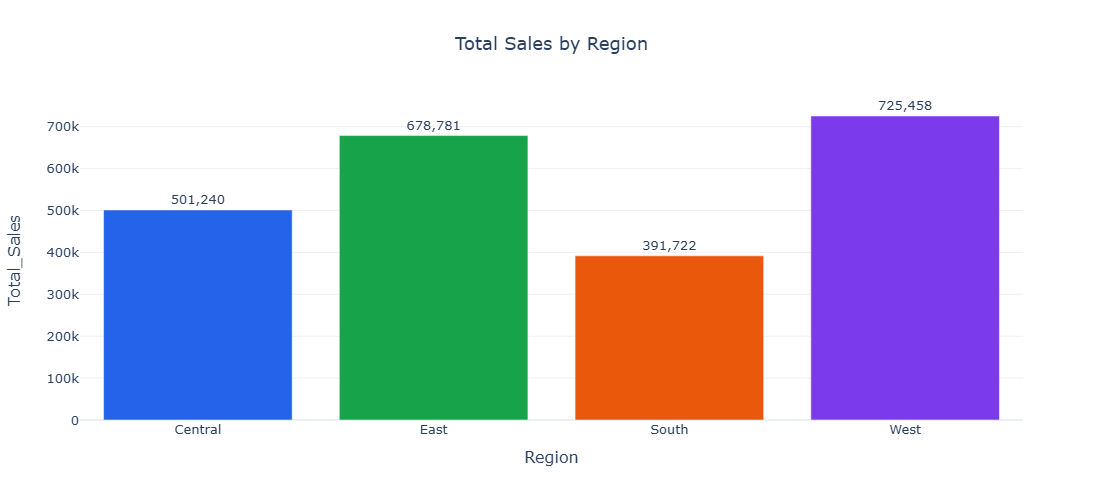

,Region,Total_Sales
0,Central,501239.8908
1,East,678781.2400
2,South,391721.9050
3,West,725457.8245


In [105]:
query("What are the total sales by Region?")


Question: What are the top 10 Product by total sales?
--------------------------------------------------
SQL:         SELECT `Product Name`, SUM(Sales) as Total_Sales FROM data GROUP BY `Product Name` ORDER BY Total_Sales DESC LIMIT 10
Explanation: This query retrieves the top 10 products based on total sales by summing the Sales for each product and ordering the results in descending order.
Chart type:  bar

Result: 10 rows returned



C:\Users\abhis\Anaconda3\Lib\site-packages\plotly\express\_core.py:1979: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



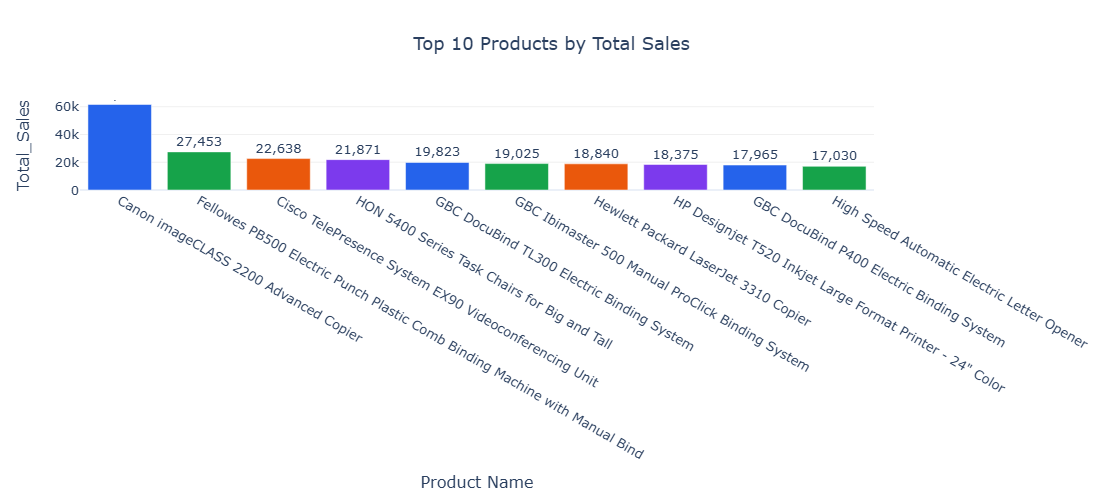

,Product Name,Total_Sales
0,Canon imageCLASS 2200 Advanced Copier,61599.824
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384
2,Cisco TelePresence System EX90 Videoconferenci...,22638.480
3,HON 5400 Series Task Chairs for Big and Tall,21870.576
4,GBC DocuBind TL300 Electric Binding System,19823.479
5,GBC Ibimaster 500 Manual ProClick Binding System,19024.500
6,Hewlett Packard LaserJet 3310 Copier,18839.686
7,HP Designjet T520 Inkjet Large Format Printer ...,18374.895
8,GBC DocuBind P400 Electric Binding System,17965.068
9,High Speed Automatic Electric Letter Opener,17030.312


In [106]:
query("What are the top 10 Product by total sales?")


In [107]:
query("what is the total revenue across all products")

Question: what is the total revenue across all products
--------------------------------------------------
SQL:         SELECT SUM(Sales) as Total_Revenue FROM data
Explanation: This query calculates the total revenue across all products by summing the Sales column.
Chart type:  metric

Result: 1 rows returned


  Total Revenue Across All Products
  ► 2,297,200.860299955


,Total_Revenue
0,2.297201e+06


Question:  Show only the top 2 products by revenue
--------------------------------------------------
SQL:         SELECT `Product Name`, SUM(Sales) as Total_Sales FROM data GROUP BY `Product Name` ORDER BY Total_Sales DESC LIMIT 2
Explanation: This query retrieves the top 2 products based on total sales by summing the Sales for each product and ordering the results in descending order.
Chart type:  bar

Result: 2 rows returned



C:\Users\abhis\Anaconda3\Lib\site-packages\plotly\express\_core.py:1979: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



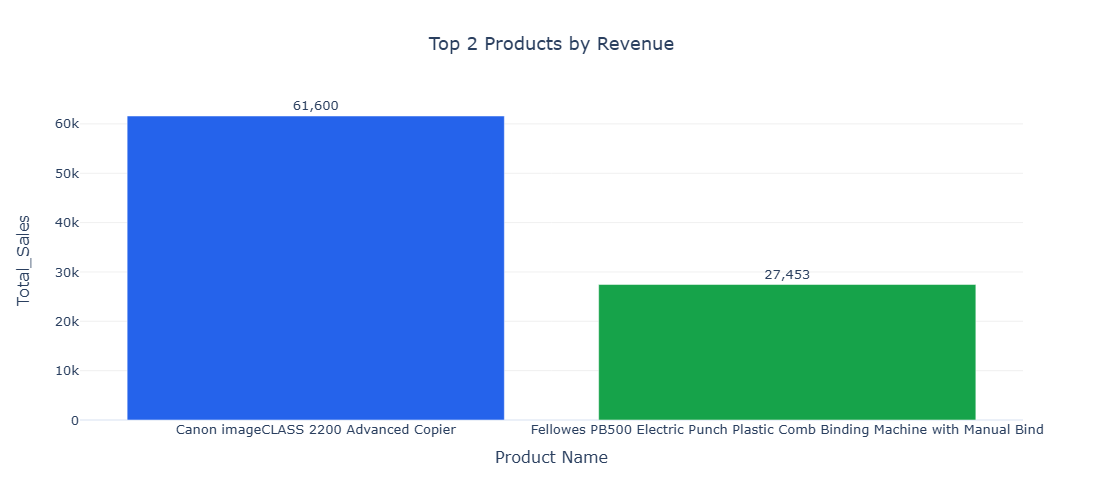

,Product Name,Total_Sales
0,Canon imageCLASS 2200 Advanced Copier,61599.824
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384


In [108]:
query(" Show only the top 2 products by revenue")